# Bogus Basin Snow Depth

In [259]:


import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pathlib import Path
import sys
from data_registry import datasets
from scipy.ndimage import uniform_filter1d
import statsmodels.formula.api as smf
import statsmodels.api as sm
import scipy.stats as stats
from scipy.interpolate import interp1d
from utils import mainutil
from prophet import Prophet

import warnings
warnings.filterwarnings("ignore")
# os.getcwd()
# os.chdir(r"C:\Users\ryanc\repo\Time-Series-Analysis-Project")
    

In [260]:
cwd = Path.cwd()
cwd

WindowsPath('c:/Users/floydry/repos/Time-Series-Analysis-Project/homework')

## Plot and Exploratory Analysis

*Read data*

In [261]:
cwd.parent

WindowsPath('c:/Users/floydry/repos/Time-Series-Analysis-Project')

In [262]:

snow_data = pd.read_csv('BogusSnowDaily.csv')
snow_data.columns = (['Date', 'Depth'])


snow_data['Date'] = pd.to_datetime(snow_data['Date'])
snow_data.set_index('Date',drop=True, inplace=True)

snow_data_monthly = snow_data.resample("ME").mean()

snow_daily = mainutil.to_ts(snow_data['Depth'], snow_data.index)
snow_monthly = mainutil.to_ts(snow_data_monthly['Depth'], snow_data_monthly.index)

print(snow_monthly.head())
print(snow_daily.head())



                   ts       pts
Date                           
1999-09-30   0.000000  0.000000
1999-10-31   0.000000  0.003236
1999-11-30   2.700000  0.006472
1999-12-31  22.580645  0.009709
2000-01-31  57.032258  0.012945
            ts       pts
Date                    
1999-09-23   0  0.000000
1999-09-24   0  0.000106
1999-09-25   0  0.000213
1999-09-26   0  0.000319
1999-09-27   0  0.000425


In [263]:
from plots.ts_plot import ts_plot
from plots.residual_plot import residual_plot

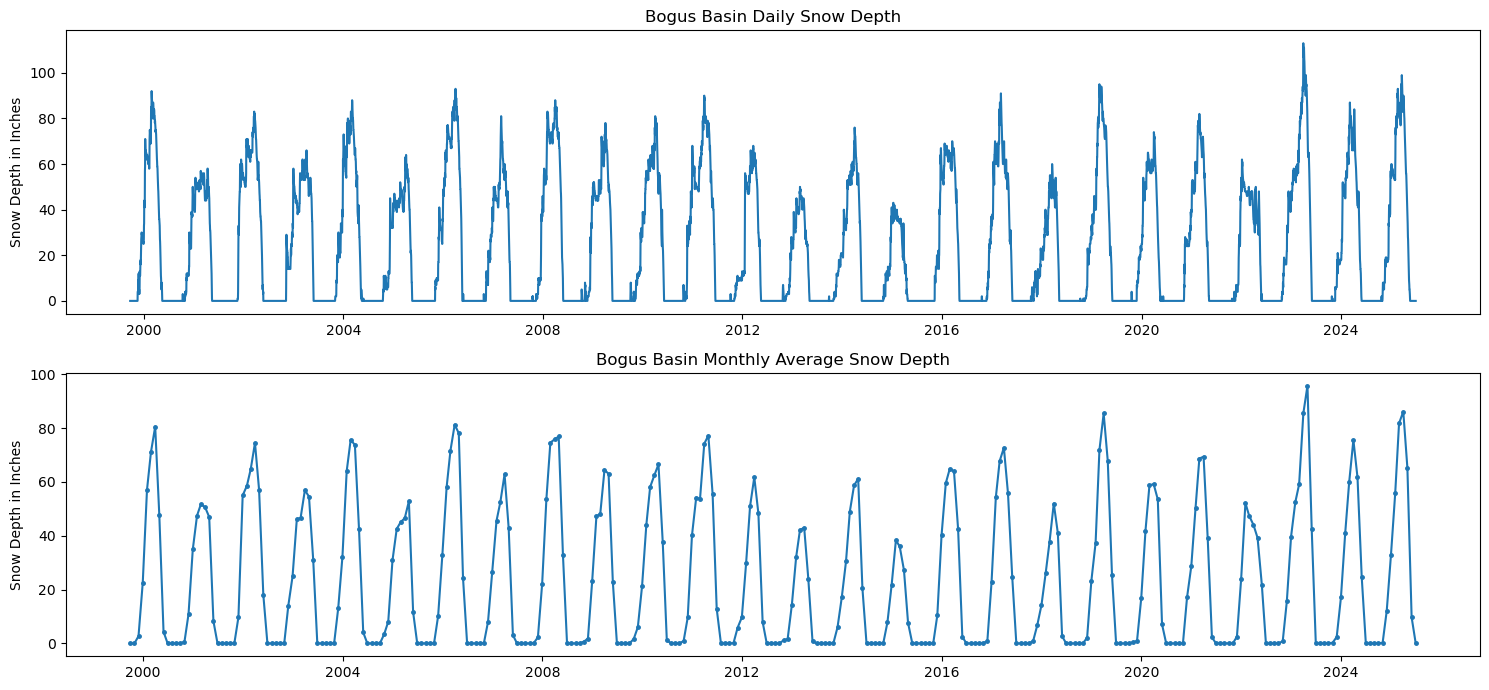

In [264]:
fig, axs = plt.subplots(2,1, figsize=(15,7))
axs[0].plot(snow_daily['ts'])
axs[0].set_title('Bogus Basin Daily Snow Depth')
axs[0].set_ylabel("Snow Depth in Inches")

axs[1].plot(snow_monthly['ts'], marker = '.', markersize = 5  )
axs[1].set_title('Bogus Basin Monthly Average Snow Depth')
axs[1].set_ylabel("Snow Depth in Inches")
fig.tight_layout()
fig.show()

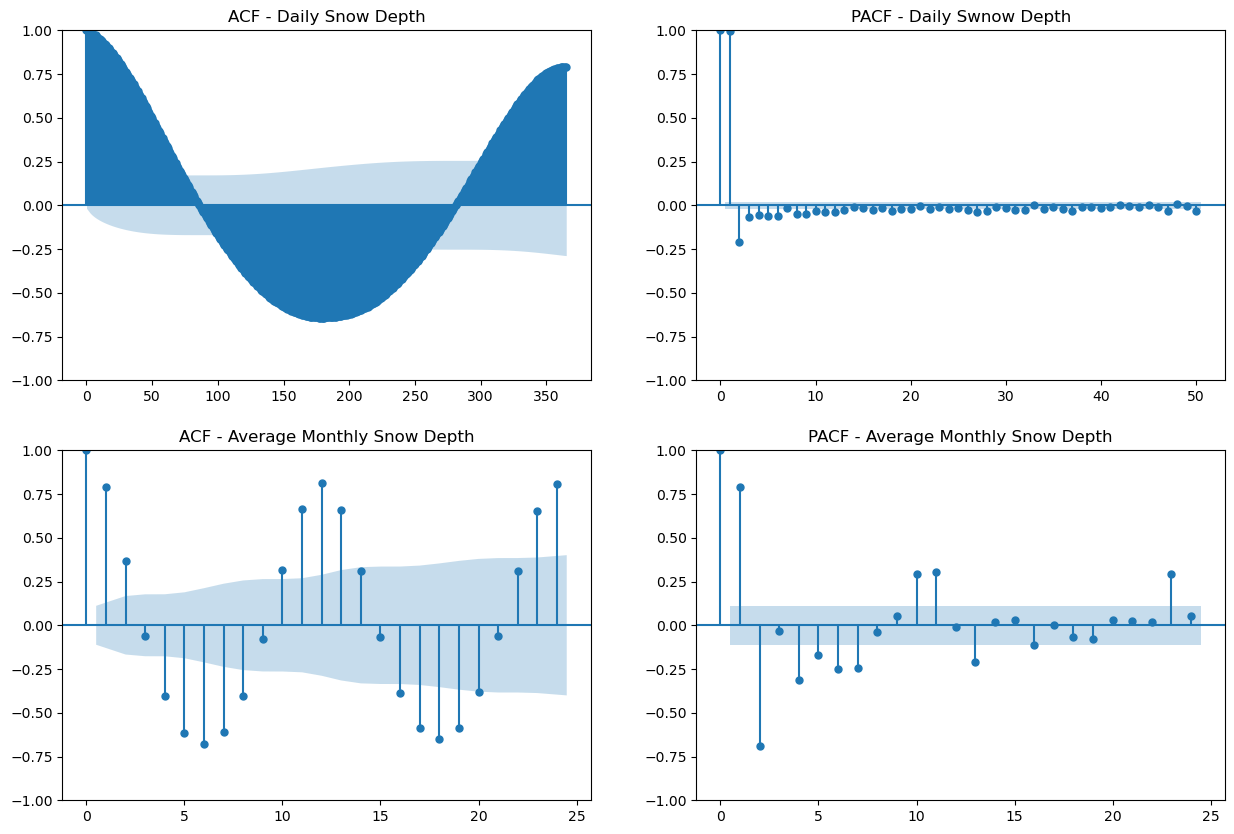

In [265]:
fig, axs = plt.subplots(2,2, figsize = (15,10))
plot_acf(snow_daily['ts'], lags = 365, ax = axs[0,0], title = 'ACF - Daily Snow Depth');
plot_pacf(snow_daily['ts'], lags = 50, ax = axs[0,1], title = "PACF - Daily Swnow Depth");

plot_acf(snow_monthly['ts'], lags = 24, ax = axs[1,0], title  = "ACF - Average Monthly Snow Depth");
plot_pacf(snow_monthly['ts'], lags = 24, ax = axs[1,1], title = 'PACF - Average Monthly Snow Depth');

## Modeling



Splitting data into training and testing data sets, with testing set for the last year's worth of data. Adding in categorical viariables at month, week, and day levels for seasonal analysis 

In [266]:
cutoff_date = '06/01/2024'

sd= snow_daily.copy()
sd['month'] = sd.index.month
sd['week'] = sd.index.isocalendar().week.astype('int')
sd['day'] = sd.index.dayofyear

sd_train = sd[sd.index<cutoff_date]
sd_test = sd[sd.index>=cutoff_date]

smnth = snow_monthly.copy()
smnth['month'] = smnth.index.month

sm_train = smnth[smnth.index<cutoff_date]
sm_test = smnth[smnth.index>=cutoff_date]

print(sd_train.tail())
print(sd_test.head())
print(sm_train.tail())
print(sm_test.head())




            ts       pts  month  week  day
Date                                      
2024-05-27   4  0.957598      5    22  148
2024-05-28   2  0.957705      5    22  149
2024-05-29   1  0.957811      5    22  150
2024-05-30   0  0.957917      5    22  151
2024-05-31   0  0.958023      5    22  152
            ts       pts  month  week  day
Date                                      
2024-06-01   0  0.958130      6    22  153
2024-06-02   0  0.958236      6    22  154
2024-06-03   0  0.958342      6    23  155
2024-06-04   0  0.958448      6    23  156
2024-06-05   0  0.958555      6    23  157
                   ts       pts  month
Date                                  
2024-01-31  40.903226  0.944984      1
2024-02-29  59.827586  0.948220      2
2024-03-31  75.580645  0.951456      3
2024-04-30  61.700000  0.954693      4
2024-05-31  24.548387  0.957929      5
                  ts       pts  month
Date                                 
2024-06-30  0.000000  0.961165      6
2024-07-31 

### Trend Estimation Using Moving Average and Local Polynomial

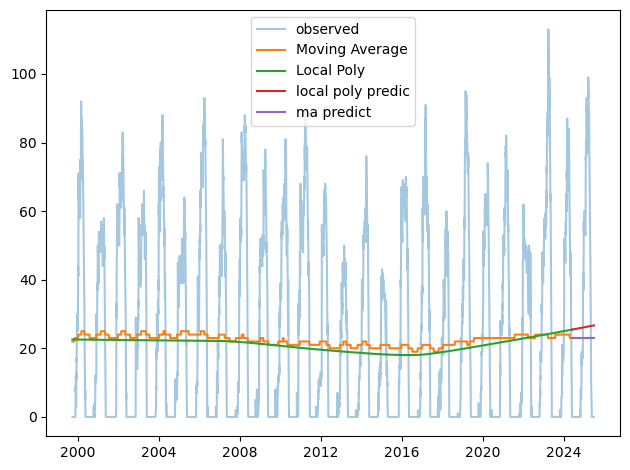

In [267]:
mavModel = uniform_filter1d(sd_train['ts'], size=len(sd_train['ts'])//2)
mavModel
mav_data = pd.Series(mavModel, index=sd_train.index)
# sd['mav2'] = snow_daily['ts'].rolling(window =365).mean()

localPolyModel = sm.nonparametric.lowess(endog=sd_train['ts'], exog=sd_train['pts'], is_sorted=True, frac=0.6)

## extrapolate local polynomial onto test data

f = interp1d(localPolyModel[:,0], localPolyModel[:,1], bounds_error=False, fill_value="extrapolate")
sd_test['LocalPoly_Trend'] = f(sd_test['pts'])

sd_test['MovingAvg_Trend'] = mav_data[-1]
#sd_test['MovingAvg_Trend'] = uniform_filter1d(sd_test['ts'], size=len(sd_test['ts'])//2)

localPolyData = pd.Series(localPolyModel[:,1], index=sd_train.index)
sd_train['MovingAvg_Trend'] = mav_data
sd_train['LocalPoly_Trend'] = localPolyData
plt.plot(sd['ts'], alpha =.4)
plt.plot(sd_train['MovingAvg_Trend'])
plt.plot(sd_train['LocalPoly_Trend'])
plt.plot(sd_test['LocalPoly_Trend'])
plt.plot(sd_test['MovingAvg_Trend'])

plt.legend(['observed', 'Moving Average', 'Local Poly', 'local poly predic', 'ma predict'])
plt.tight_layout()

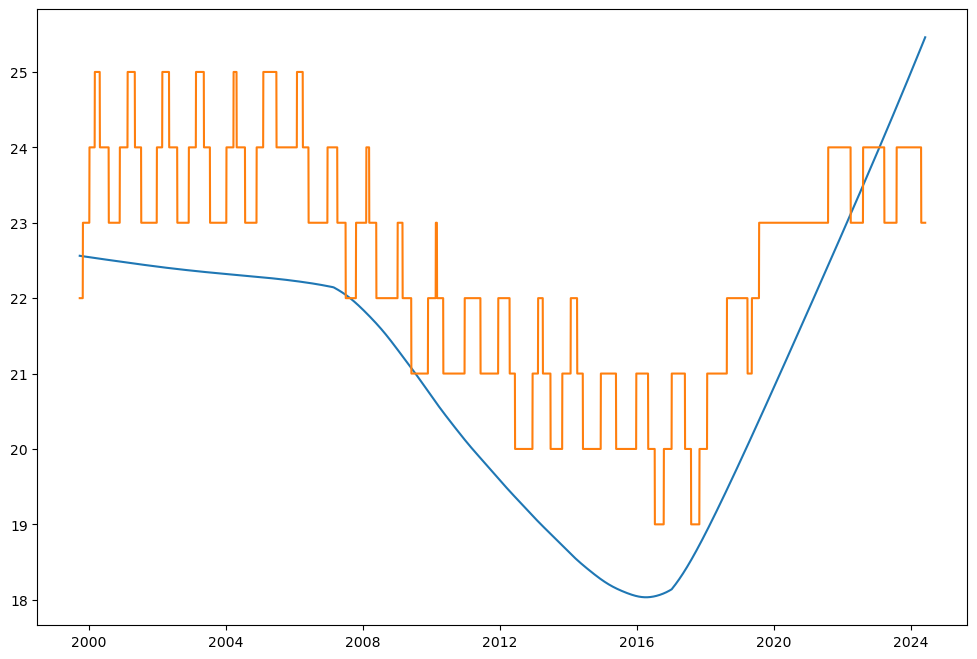

In [268]:
plt.figure(figsize = (12,8))
plt.plot(sd_train['LocalPoly_Trend'])
plt.plot(sd_train['MovingAvg_Trend'])

### Seaonality Estimation

In [269]:
def generate_fourier_terms(time, period, K):
    """
    Generate Fourier terms for a given time series.

    Parameters:
    - time: array-like, time index
    - period: int, seasonal period
    - K: int, number of harmonics

    Returns:
    - DataFrame containing sine and cosine terms
    """
    fourier_terms = {}
    for k in range(1, K + 1):
        fourier_terms[f'sin_{k}'] = np.sin(2 * np.pi * k * time / period)
        fourier_terms[f'cos_{k}'] = np.cos(2 * np.pi * k * time / period)
    return pd.DataFrame(fourier_terms)


f_train = generate_fourier_terms(sd_train.index.dayofyear, 365, 3)


In [270]:
f_train =f_train.set_index(sd_train.index)
f_train

,sin_1,cos_1,sin_2,cos_2,sin_3,cos_3
Date,,,,,,
1999-09-23,-0.991114,-0.133015,0.263665,-0.964614,0.920971,0.389630
1999-09-24,-0.993257,-0.115935,0.230306,-0.973118,0.939856,0.341571
1999-09-25,-0.995105,-0.098820,0.196673,-0.980469,0.956235,0.292600
1999-09-26,-0.996659,-0.081676,0.162807,-0.986658,0.970064,0.242850
1999-09-27,-0.997917,-0.064508,0.128748,-0.991677,0.981306,0.192452
...,...,...,...,...,...,...
2024-05-27,0.559589,-0.828770,-0.927542,0.373720,0.977848,0.209315
2024-05-28,0.545240,-0.838280,-0.914128,0.405426,0.987349,0.158559
2024-05-29,0.530730,-0.847541,-0.899631,0.436651,0.994218,0.107381


In [271]:
sd_train =sd_train.join(f_train)


In [272]:


#sd_train['mavtrend'] = mav_data
sd_train['ts_sqrt'] = np.sqrt(sd_train['ts'])
#sd_train['ts_log'] = np.log(sd_train['ts']+1)
# sd_train['cos1'] = np.cos(2 * np.pi * (sd_train.index.dayofyear - 1) / 365)
# sd_train['sin1'] = np.sin(2 * np.pi * (sd_train.index.dayofyear - 1) / 365)
# sd_train['cos2'] = np.cos(2 * np.pi * (sd_train.index.month - 1) / 365)
# sd_train['sin2'] = np.sin(2 * np.pi * (sd_train.index.month - 1) /365)


# seasonalmodel_no_trend = smf.ols(formula = 'ts_sqrt~ sin1 + cos1', data = sd_train).fit()
# seasonalmodel_MA_trend = smf.ols(formula = 'ts_sqrt~ sin1 + cos1+ + cos2 + sin2 +MovingAvg_Trend', data = sd_train).fit()
#seasonalmodel_LocalPoly_trend_myf = smf.ols(formula = 'ts_sqrt~ sin1 + cos1+ +cos2 +sin2+ LocalPoly_Trend', data = sd_train).fit()
seasonalmodel_LocalPoly_trend_Harmonic2 = smf.ols(formula = 'ts_sqrt~ sin_1 + cos_1+ +cos_2 +sin_2+ LocalPoly_Trend', data = sd_train).fit()
seasonalmodel_LocalPoly_trend_Harmonic3 = smf.ols(formula = 'ts_sqrt~ sin_1 + cos_1+ +cos_2 +sin_2+ +cos_3 + sin_3+ LocalPoly_Trend', data = sd_train).fit()
# seasonal_model_WeeklyAnova_w_Poly = smf.ols(formula = 'ts_sqrt~C(week)+MovingAvg_Trend', data = sd_train).fit()
# seasonal_model_DailyAnova_w_Poly = smf.ols(formula = 'ts_sqrt~C(day)+MovingAvg_Trend', data = sd_train).fit()


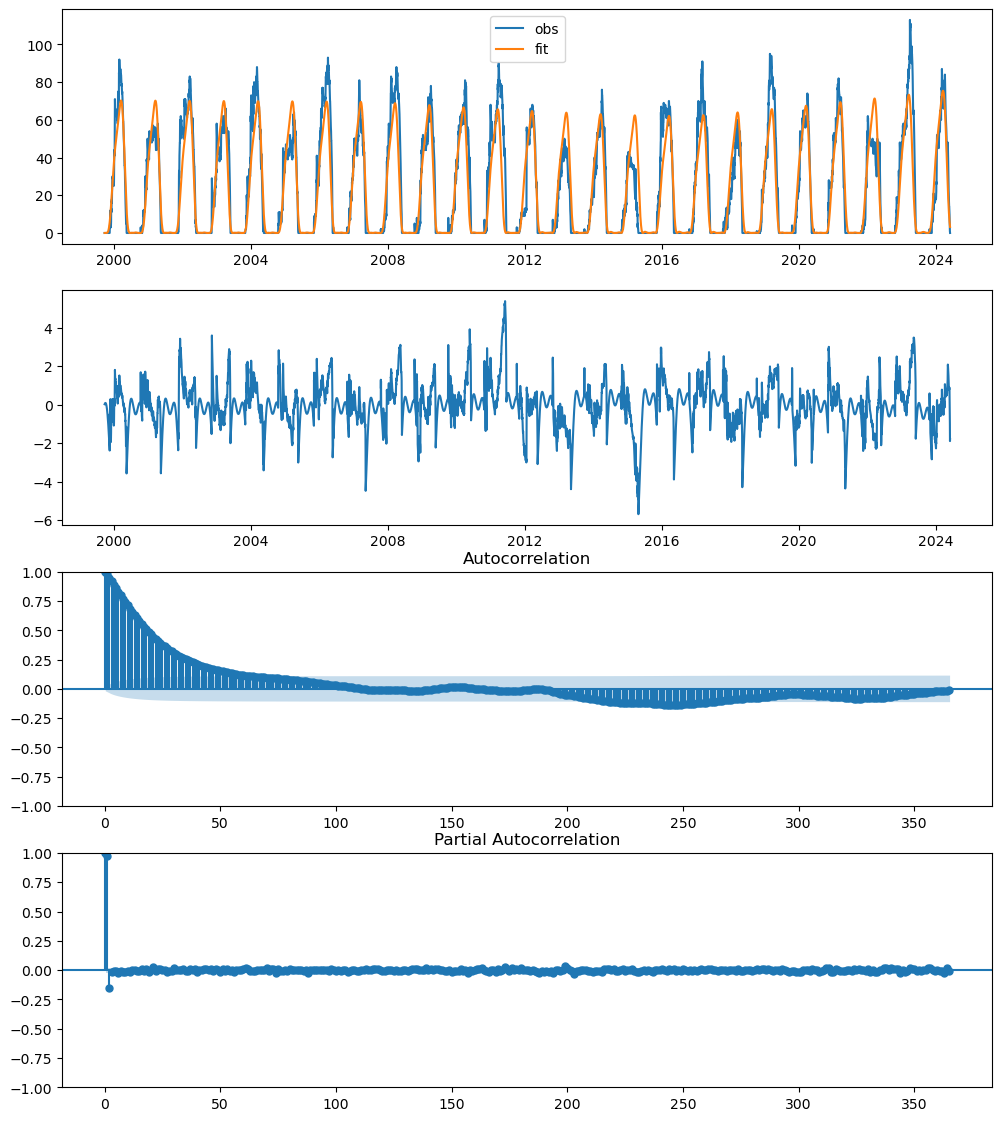

In [273]:
fig, axs = plt.subplots(4,1, figsize =(12,14) )
axs[0].plot(sd_train['ts'])
axs[0].plot(seasonalmodel_LocalPoly_trend_Harmonic3.fittedvalues**2)
#axs[0].plot(seasonalmodel_LocalPoly_trend_Harmonic2.fittedvalues**2)

axs[1].plot(seasonalmodel_LocalPoly_trend_Harmonic3.resid)
axs[0].legend(['obs', 'fit',])

plot_acf(seasonalmodel_LocalPoly_trend_Harmonic3.resid, lags = 365, ax = axs[2]);
plot_pacf(seasonalmodel_LocalPoly_trend_Harmonic3.resid, lags = 365, ax = axs[3]);
#plt.plot(seasonalmodel.params)

In [274]:
f_test = generate_fourier_terms(sd_test.index.dayofyear, 365, 3)
f_test = f_test.set_index(sd_test.index)
sd_test = sd_test.join(f_test)

In [275]:
sd_test

,ts,pts,month,week,day,LocalPoly_Trend,MovingAvg_Trend,sin_1,cos_1,sin_2,cos_2,sin_3,cos_3
Date,,,,,,,,,,,,,
2024-06-01,0,0.958130,6,22,153,25.463000,23,0.486273,-0.873807,-0.849817,0.527078,0.998880,-0.047321
2024-06-02,0,0.958236,6,22,154,25.466076,23,0.471160,-0.882048,-0.831171,0.556017,0.995105,-0.098820
2024-06-03,0,0.958342,6,23,155,25.469153,23,0.455907,-0.890028,-0.811539,0.584298,0.988678,-0.150055
2024-06-04,0,0.958448,6,23,156,25.472229,23,0.440519,-0.897743,-0.790946,0.611886,0.979614,-0.200891
2024-06-05,0,0.958555,6,23,157,25.475306,23,0.425000,-0.905193,-0.769415,0.638749,0.967938,-0.251190
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-26,0,0.999575,6,26,177,26.662841,23,0.094537,-0.995521,-0.188227,0.982126,0.280231,-0.959933
2025-06-27,0,0.999681,6,26,178,26.665917,23,0.077386,-0.997001,-0.154309,0.988023,0.230306,-0.973118
2025-06-28,0,0.999787,6,26,179,26.668994,23,0.060213,-0.998186,-0.120208,0.992749,0.179767,-0.983709


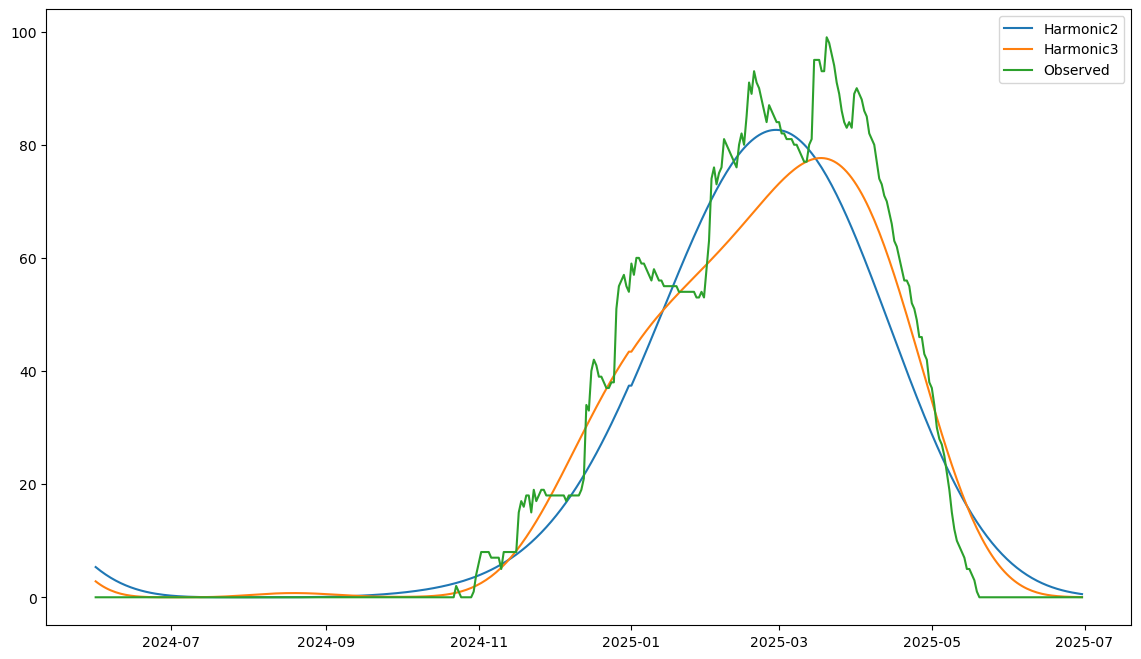

In [276]:

sd_test['ts_sqrt'] = np.sqrt(sd_test['ts'])
sd_test['ts_log'] = np.log(sd_test['ts']+1)
# sd_test['cos1'] = np.cos(2 * np.pi * (sd_test.index.dayofyear - 1) / 365)
# sd_test['sin1'] = np.sin(2 * np.pi * (sd_test.index.dayofyear - 1) / 365)
# sd_test['cos2'] = np.cos(4 * np.pi * (sd_test.index.month - 1) / 180)
# sd_test['sin2'] = np.sin(4 * np.pi * (sd_test.index.month - 1) / 180)

plt.figure( figsize = (14,8))
#plt.plot(seasonalmodel_LocalPoly_trend_myf.predict(exog = sd_test)**2)
plt.plot(seasonalmodel_LocalPoly_trend_Harmonic2.predict(exog = sd_test)**2)
plt.plot(seasonalmodel_LocalPoly_trend_Harmonic3.predict(exog = sd_test)**2)
#plt.plot(seasonalmodel_no_trend.predict(exog=sd_test)**2)
# plt.plot(seasonalmodel_LocalPoly_trend.predict(exog=sd_test)**2)
# plt.plot(seasonalmodel_MA_trend.predict(exog=sd_test)**2)
# plt.plot(seasonal_model_WeeklyAnova_w_Poly.predict(exog=sd_test)**2)
# plt.plot(seasonal_model_DailyAnova_w_Poly.predict(exog=sd_test)**2)
plt.plot(sd_test['ts'])
plt.legend(['Harmonic2', 'Harmonic3', 'Observed'])

In [323]:
maxp=4
maxd=2
maxq=4

best_bic = np.inf
selected_orders = (0,0,0)

for p in range(maxp+1):
    for q in range(maxq+1):
        for d in range(maxd):
            orders = (p,d,q)
            model = sm.tsa.statespace.SARIMAX(
                sd_train['ts'], 
                exog = f_train,
                order=orders                   
                        )

    results = model.fit()
    bic = results.bic
    if bic < best_bic:
        best_bic = bic
        selected_orders = orders

print(selected_orders, bic)

(0, 1, 4) 36307.089148612715


In [324]:
arima_fourier_model =sm.tsa.statespace.SARIMAX(
                sd_train['ts'], 
                exog = f_train,
                order=selected_orders ).fit()
print(arima_fourier_model.summary())


                               SARIMAX Results                                
Dep. Variable:                     ts   No. Observations:                 9016
Model:               SARIMAX(0, 1, 4)   Log Likelihood              -18093.921
Date:                Thu, 23 Apr 2026   AIC                          36209.842
Time:                        12:00:55   BIC                          36288.015
Sample:                             0   HQIC                         36236.440
                               - 9016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sin_1         27.9409      3.704      7.544      0.000      20.682      35.200
cos_1         17.8729      3.599      4.965      0.000      10.818      24.928
sin_2          8.4882      2.535      3.349      0.0

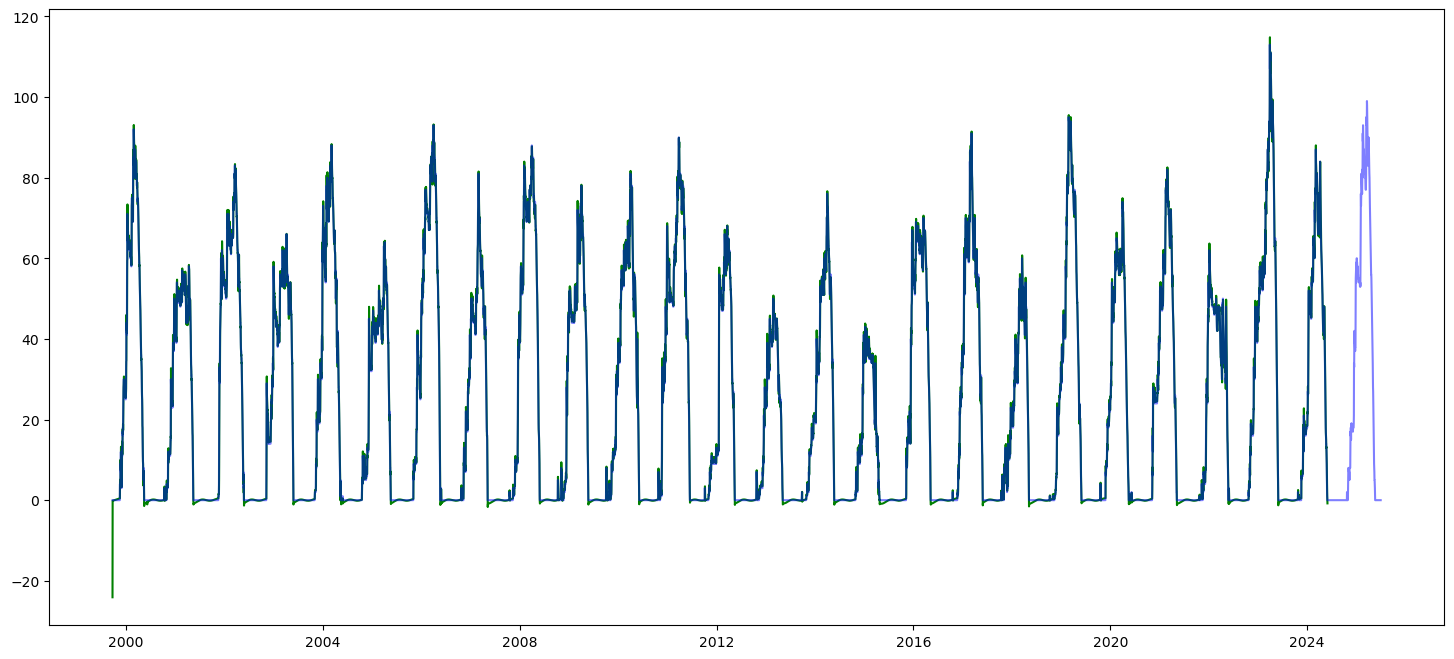

In [326]:
plt.figure(figsize= (18,8))
plt.plot(arima_fourier_model.fittedvalues, color = 'green')
plt.plot(sd['ts'], alpha=.5 ,color = 'blue')
forecast= arima_fourier_model.forecast(steps = 395, exog = f_test)


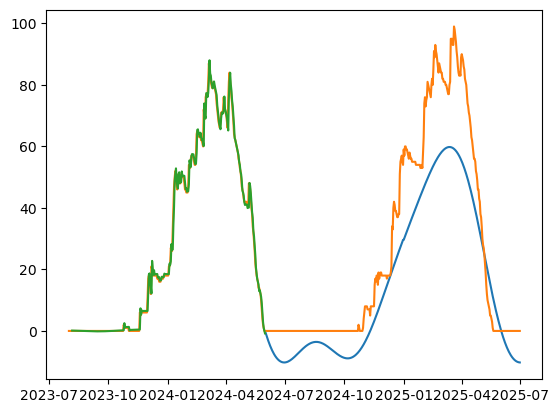

In [ ]:
plt.plot(sd_test.index, forecast )
plt.plot(sd['ts'][-700:])
plt.plot(arima_fourier_model.fittedvalues[-300:])


In [356]:
prof_train = pd.DataFrame( sd_train.index, sd_train.copy()['ts']).reset_index()

prof_train.rename(columns={'ts':'y', 'Date':'ds'}, inplace=True)
prof_train.head()

,y,ds
0,0,1999-09-23
1,0,1999-09-24
2,0,1999-09-25
3,0,1999-09-26
4,0,1999-09-27


12:50:31 - cmdstanpy - INFO - Chain [1] start processing
12:50:33 - cmdstanpy - INFO - Chain [1] done processing


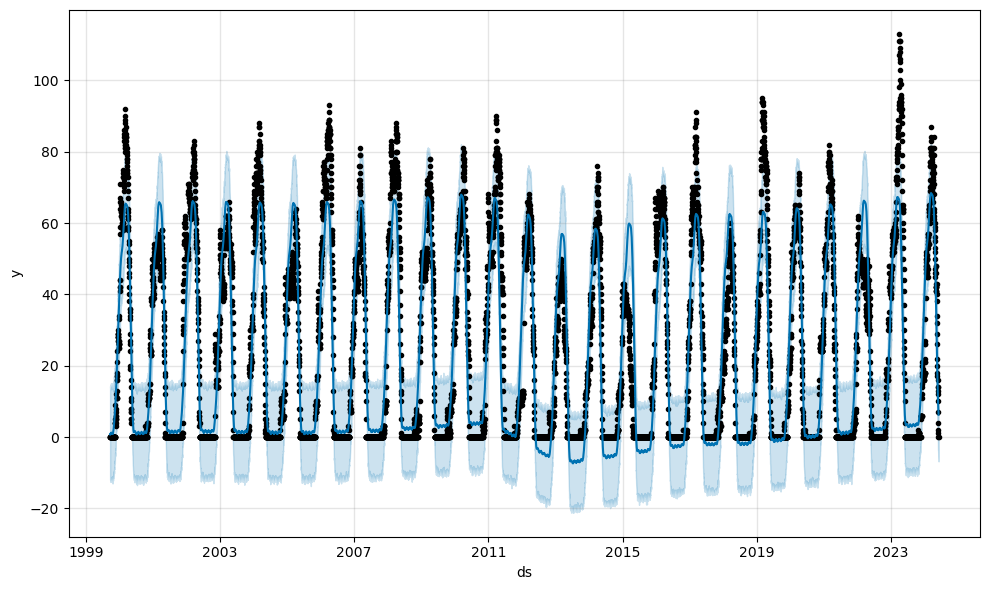

In [358]:
m = Prophet()
m.fit(prof_train)
forecast = m.predict(prof_train)
plot = m.plot(forecast)
plot.show()

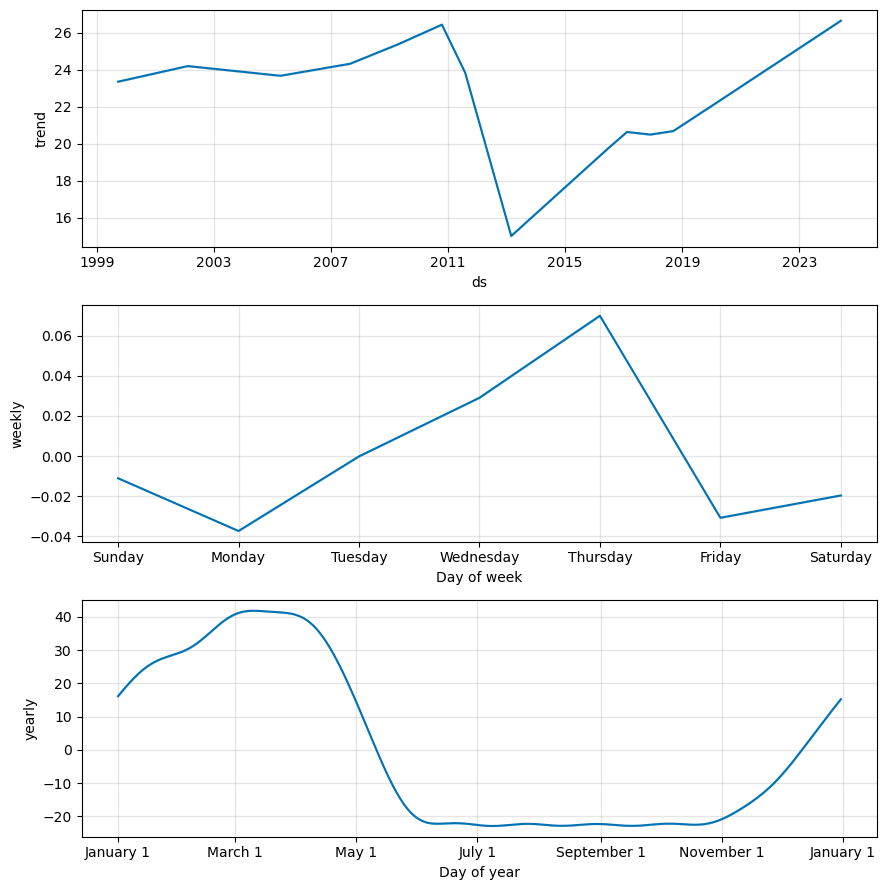

In [359]:
plot=m.plot_components(forecast)
plot.show()